## Some Preliminary Attempts

In [ ]:
import os
import numpy as np
from cytools import fetch_polytopes

os.makedirs("csv", exist_ok=True)

h11 = 3  # you can change this
polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=5)

# Loop over the first two CY3s (you can extend this)
for cy_index, p in enumerate(polys[:2]):
    print(f"\n=== Processing polytope {cy_index} with h11 = {h11} ===")
    
    # Create subfolder for this CY3
    cy_folder = f"csv's/CY3_{cy_index}"
    os.makedirs(cy_folder, exist_ok=True)
    
    # Triangulate and build CY
    t = p.triangulate(backend="topcom")
    cy = t.get_cy()
    
    # Triple intersection numbers
    kappa = cy.intersection_numbers(in_basis=True)
    with open(f"{cy_folder}/triple_intersections.csv", "w", newline="") as f:
        import csv
        writer = csv.writer(f)
        writer.writerow(["i", "j", "k", "value"])
        for inds, val in kappa.items():
            writer.writerow([*inds, val])
    
    mori = cy.toric_mori_cone(in_basis=True)
    rays = mori.rays()
    
    # Rays
    with open(f"{cy_folder}/mori_rays.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ray_index"] + [f"x{n}" for n in range(len(rays[0]))])
        for i, r in enumerate(rays):
            writer.writerow([i] + list(r))
    
    # Pairwise cosines
    with open(f"{cy_folder}/mori_cosines.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["i", "j", "cos_theta"])
        for i in range(len(rays)):
            for j in range(i+1, len(rays)):
                cosij = np.dot(rays[i], rays[j]) / (np.linalg.norm(rays[i]) * np.linalg.norm(rays[j]))
                writer.writerow([i, j, cosij])
    
    # Kähler cone tip
    kahler = cy.toric_kahler_cone()
    tip = kahler.tip_of_stretched_cone(1)
    with open(f"{cy_folder}/kahler_tip.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["tip_index", "value"])
        for i, val in enumerate(tip):
            writer.writerow([i, val])
        writer.writerow(["norm_tip", np.linalg.norm(tip)])
    
    # CY volume
    vol = cy.compute_cy_volume(tip)
    with open(f"{cy_folder}/volumes.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["volume_type", "value"])
        writer.writerow(["CY_volume", vol])
        writer.writerow(["log10_CY_volume", np.log10(vol)])
    
    # Divisor volumes
    divvols = cy.compute_divisor_volumes(tip)
    with open(f"{cy_folder}/divisor_volumes.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["divisor_index", "volume"])
        for i, v in enumerate(divvols):
            writer.writerow([i, v])
    
    # Axion kinetic matrix
    K = cy.compute_kahler_metric(tip)
    with open(f"{cy_folder}/axion_K.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["i", "j", "K_ij"])
        for i in range(K.shape[0]):
            for j in range(K.shape[1]):
                writer.writerow([i, j, K[i,j]])
    
    # Axion eigenvalues, decay constants, and eigenvectors
    evals, evecs = np.linalg.eigh(K)
    
    with open(f"{cy_folder}/axion_evals.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["i", "eigenvalue", "decay_constant"])
        for i, lam in enumerate(evals):
            writer.writerow([i, lam, 1/np.sqrt(lam)])
    
    with open(f"{cy_folder}/axion_evecs.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["eigenvector_index", "component_index", "value"])
        for i in range(evecs.shape[1]):
            for j in range(evecs.shape[0]):
                writer.writerow([i, j, evecs[j,i]])
    
    # Axion-photon couplings
    c = np.array([1,0,0])
    with open(f"{cy_folder}/axion_photon.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["i", "g_relative"])
        for i in range(len(evals)):
            g = np.dot(c, evecs[:,i])
            writer.writerow([i, g])
    
    print(f"Saved all CSVs for CY3_{cy_index} in {cy_folder}")

In [ ]:
import os
import csv
import numpy as np
from cytools import fetch_polytopes

os.makedirs("csv", exist_ok=True)


h11_dict = {
    3: 2,  # 2 CY3s at h11 = 3
    5: 2,  # 3 CY3s at h11 = 5
}

file_paths = {
    "triple_intersections": "csv/triple_intersections.csv",
    "mori_rays": "csv/mori_rays.csv",
    "mori_cosines": "csv/mori_cosines.csv",
    "kahler_tip": "csv/kahler_tip.csv",
    "volumes": "csv/volumes.csv",
    "divisor_volumes": "csv/divisor_volumes.csv",
    "axion_K": "csv/axion_K.csv",
    "axion_evals": "csv/axion_evals.csv",
    "axion_evecs": "csv/axion_evecs.csv",
    "axion_photon": "csv/axion_photon.csv",
}

headers = {
    "triple_intersections": ["h11","CY3_index","i","j","k","value"],
    "mori_rays": ["h11","CY3_index","ray_index","x0","x1","x2"],
    "mori_cosines": ["h11","CY3_index","i","j","cos_theta"],
    "kahler_tip": ["h11","CY3_index","tip_index","value"],
    "volumes": ["h11","CY3_index","volume_type","value"],
    "divisor_volumes": ["h11","CY3_index","divisor_index","volume"],
    "axion_K": ["h11","CY3_index","i","j","K_ij"],
    "axion_evals": ["h11","CY3_index","i","eigenvalue","decay_constant"],
    "axion_evecs": ["h11","CY3_index","eigenvector_index","component_index","value"],
    "axion_photon": ["h11","CY3_index","i","g_relative"],
}

for key, path in file_paths.items():
    with open(path, "w", newline="") as f:
        csv.writer(f).writerow(headers[key])

for h11, n_cy3 in h11_dict.items():
    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")
    
    polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=n_cy3)
    
    for cy_index, p in enumerate(polys):
        print(f"Processing CY3 {cy_index} at h11={h11}...")
        
        t = p.triangulate(backend="topcom")
        cy = t.get_cy()
        
        # Triple intersection numbers
        kappa = cy.intersection_numbers(in_basis=True)
        with open(file_paths["triple_intersections"], "a", newline="") as f:
            writer = csv.writer(f)
            for inds, val in kappa.items():
                writer.writerow([h11, cy_index, *inds, val])
        
        # Mori rays
        mori = cy.toric_mori_cone(in_basis=True)
        rays = mori.rays()
        with open(file_paths["mori_rays"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, r in enumerate(rays):
                writer.writerow([h11, cy_index, i, *r])
        
        # mori cosine rays
        with open(file_paths["mori_cosines"], "a", newline="") as f:
            writer = csv.writer(f)
            for i in range(len(rays)):
                for j in range(i+1, len(rays)):
                    cosij = np.dot(rays[i], rays[j]) / (np.linalg.norm(rays[i])*np.linalg.norm(rays[j]))
                    writer.writerow([h11, cy_index, i, j, cosij])
        
        # Kähler tip
        kahler = cy.toric_kahler_cone()
        tip = kahler.tip_of_stretched_cone(1)
        with open(file_paths["kahler_tip"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, val in enumerate(tip):
                writer.writerow([h11, cy_index, i, val])
            writer.writerow([h11, cy_index, "norm_tip", np.linalg.norm(tip)])
        
        # CY3 Volumes
        vol = cy.compute_cy_volume(tip)
        with open(file_paths["volumes"], "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([h11, cy_index, "CY_volume", vol])
            writer.writerow([h11, cy_index, "log10_CY_volume", np.log10(vol)])
        
        # Divisor volumes
        divvols = cy.compute_divisor_volumes(tip)
        with open(file_paths["divisor_volumes"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, v in enumerate(divvols):
                writer.writerow([h11, cy_index, i, v])
        
        # Axion kinetic matrix
        K = cy.compute_kahler_metric(tip)
        with open(file_paths["axion_K"], "a", newline="") as f:
            writer = csv.writer(f)
            for i in range(K.shape[0]):
                for j in range(K.shape[1]):
                    writer.writerow([h11, cy_index, i, j, K[i,j]])
        
        # Axion eigenvalues and decay constants
        evals, evecs = np.linalg.eigh(K)
        with open(file_paths["axion_evals"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, lam in enumerate(evals):
                writer.writerow([h11, cy_index, i, lam, 1/np.sqrt(lam)])
        
        # Axion eigenvectors
        with open(file_paths["axion_evecs"], "a", newline="") as f:
            writer = csv.writer(f)
            for i in range(evecs.shape[1]):
                for j in range(evecs.shape[0]):
                    writer.writerow([h11, cy_index, i, j, evecs[j,i]])
        
        # Axion-photon couplings
        c = np.zeros(len(evals))  # length = number of axions
        c[0] = 1                  # only first divisor couples
        with open(file_paths["axion_photon"], "a", newline="") as f:
            writer = csv.writer(f)
            for i in range(len(evals)):
                g = np.dot(c, evecs[:,i])
                writer.writerow([h11, cy_index, i, g])

print("\n=== All done! ===")
print("All specified CY3s processed and saved in 'csv/' folder.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "text.usetex": True,      
    "font.family": "serif",   
    "font.serif": ["Computer Modern Roman"],  
    "font.size": 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

axion_df = pd.read_csv("csv/axion_photon.csv")
evals_df = pd.read_csv("csv/axion_evals.csv")

df = pd.merge(axion_df, evals_df, on=["h11","CY3_index","i"])

df["g_abs"] = df["g_relative"].abs()
df["f"] = df["decay_constant"]

marker_dict = {3: "*", 5: "D"}
color_dict = {3: "red", 5: "blue"}

plt.figure(figsize=(7,5))

for h11_val in marker_dict.keys():
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["f"], sub["g_abs"], 
        marker=marker_dict[h11_val], 
        color=color_dict[h11_val],
        edgecolor='k', s=100, 
        label=rf"$h^{{1,1}}={h11_val}$"  
    )

plt.xlabel(r"Decay constant $f_i$ $(M_P$ units)")
plt.ylabel(r"Axion-photon coupling $|g_{a\gamma\gamma}|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cytools import fetch_polytopes

os.makedirs("csv", exist_ok=True)

h11_dict = {
    3: 1
}

file_paths = {
    "axion_photon": "csv/axion_photon.csv",
    "axion_evals": "csv/axion_evals.csv",
    "axion_masses": "csv/axion_masses.csv"
}

with open(file_paths["axion_photon"], "w", newline="") as f:
    csv.writer(f).writerow(["h11", "CY3_index", "i", "g_relative"])

with open(file_paths["axion_evals"], "w", newline="") as f:
    csv.writer(f).writerow(["h11", "CY3_index", "i", "eigenvalue", "decay_constant"])

with open(file_paths["axion_masses"], "w", newline="") as f:
    csv.writer(f).writerow(["h11", "CY3_index", "i", "mass"])

for h11, n_cy3 in h11_dict.items():
    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):
        print(f"Processing CY3 {cy_index} at h11={h11}...")

        # Geometry 
        t = p.triangulate(backend="topcom")
        cy = t.get_cy()

        kahler = cy.toric_kahler_cone()
        tip = kahler.tip_of_stretched_cone(1)

        # Volume rescaling
        V = cy.compute_cy_volume(tip)
        tip_scaled = tip / V**(1/3)
        V_scaled = cy.compute_cy_volume(tip_scaled)

        print(f"Original volume: {V:.2f}, scaled volume: {V_scaled:.2f}")

        # Axion kinetic matrix
        K = cy.compute_kahler_metric(tip_scaled)
        evals_K, evecs_K = np.linalg.eigh(K)

        decay_constants = 1 / np.sqrt(evals_K)

        # Decay constants
        with open(file_paths["axion_evals"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, lam in enumerate(evals_K):
                writer.writerow([h11, cy_index, i, lam, decay_constants[i]])

        # Axion–photon couplings
        c = np.zeros(len(evals_K))
        c[0] = 1.0  # choose one divisor for photon coupling

        g_rel = [np.dot(c, evecs_K[:, i]) for i in range(len(evals_K))]

        with open(file_paths["axion_photon"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, g in enumerate(g_rel):
                writer.writerow([h11, cy_index, i, g])

        # Axion masses 
        taus = cy.compute_divisor_volumes(tip_scaled)
        taus = np.array(taus[:h11])

        Lambda4 = np.exp(-2 * np.pi * taus)
        M2_geom = np.diag(Lambda4)

        K_inv_sqrt = (
            evecs_K
            @ np.diag(1 / np.sqrt(evals_K))
            @ evecs_K.T
        )

        M2_phys = K_inv_sqrt @ M2_geom @ K_inv_sqrt

        m2, _ = np.linalg.eigh(M2_phys)
        masses = np.sqrt(np.abs(m2))

        print("Axion masses:", masses)
        print("log10 masses:", np.log10(masses))
        print(f"h11={h11}, CY={cy_index}, masses={masses}")

        with open(file_paths["axion_masses"], "a", newline="") as f:
            writer = csv.writer(f)
            for i, m in enumerate(masses):
                writer.writerow([h11, cy_index, i, m])

print("\nAll CY3s processed and saved in CSVs!")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import itertools

axion_df = pd.read_csv(file_paths["axion_photon"])
evals_df = pd.read_csv(file_paths["axion_evals"])
df = pd.merge(axion_df, evals_df, on=["h11","CY3_index","i"])
df["g_abs"] = df["g_relative"].abs()
df["f"] = df["decay_constant"]

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]  
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"] 

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict = {h: next(color_cycle) for h in h11_unique}

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

plt.figure(figsize=(7,5))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["f"], sub["g_abs"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}$"
    )

plt.xlabel(r"Decay constant $f_i$ $(M_P$ units)")
plt.ylabel(r"Axion-Photon coupling $|g_{a\gamma\gamma}|$")
plt.title(r"Axion-Photon coupling vs Decay constant")

leg = plt.legend(frameon=True)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(1)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools

axion_df = pd.read_csv(file_paths["axion_photon"])
evals_df = pd.read_csv(file_paths["axion_evals"])
mass_df  = pd.read_csv(file_paths["axion_masses"])

df = axion_df.merge(evals_df, on=["h11","CY3_index","i"])
df = df.merge(mass_df, on=["h11","CY3_index","i"])

df["g_abs"] = df["g_relative"].abs()
df["f"] = df["decay_constant"]
df["log10_mass"] = np.log10(df["mass"])

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]  
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"] 

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict = {h: next(color_cycle) for h in h11_unique}

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

plt.figure(figsize=(7,5))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_mass"],
        sub["g_abs"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k',
        s=100,
        label=rf"$h^{{1,1}}={h11_val}$"
    )

plt.xlabel(r"$\log_{10}(m_a)$ ($M_p$ units)")
plt.ylabel(r"Axion-Photon coupling $|g_{a\gamma\gamma}|$")
plt.title(r"Axion-Photon coupling vs Axion mass")

leg = plt.legend(frameon=True)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(1)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

axion_df = pd.read_csv(file_paths["axion_photon"])
evals_df = pd.read_csv(file_paths["axion_evals"])
mass_df  = pd.read_csv(file_paths["axion_masses"])

df = axion_df.merge(evals_df, on=["h11","CY3_index","i"])
df = df.merge(mass_df, on=["h11","CY3_index","i"])

df["g_abs"] = df["g_relative"].abs()
df["f"] = df["decay_constant"]
df["log10_mass"] = np.log10(df["mass"])

cy3_counts = (
    df.groupby("h11")["CY3_index"]
      .nunique()
      .to_dict()
)

df.groupby("h11").size()
print(df.groupby("h11").size())

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]  
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"] 

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict = {h: next(color_cycle) for h in h11_unique}

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

plt.figure(figsize=(15,9))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["f"], sub["g_abs"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}\ ({cy3_counts[h11_val]})$"
    )

plt.xlabel(r"Decay constant $f_i$ $(M_P$ units)",fontsize=30)
plt.ylabel(r"Axion-Photon coupling $|g_{a\gamma\gamma}|$",fontsize=30)
plt.title(r"Axion-Photon coupling vs Decay constant",fontsize=30)

leg = plt.legend(loc="upper right", frameon=True)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(1)

plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,9))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_mass"], sub["g_abs"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}\ ({cy3_counts[h11_val]})$"
    )

plt.xlabel(r"$\log_{10}(m_a)$ ($M_P$ units)", fontsize=30)
plt.ylabel(r"Axion-Photon coupling $|g_{a\gamma\gamma}|$",fontsize=30)
plt.title(r"Axion-Photon coupling vs Axion mass",fontsize=30)

leg = plt.legend(loc="upper right", frameon=True)
frame = leg.get_frame()
frame.set_edgecolor('black')
frame.set_linewidth(1)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from cytools import calabiyau, fetch_polytopes

h11_dict = {
    100: 25,
    200: 25,
    491: 1
}

alpha_em = 1 / 137

records = []

for h11, n_cy3 in h11_dict.items():
    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):
        print(f"Processing CY3 {cy_index} at h11={h11}...")
        t = p.triangulate(backend="topcom")
        cy = t.get_cy()

        tip = cy.toric_kahler_cone().tip_of_stretched_cone(1)
        n_axions = len(tip)

        K = cy.compute_kahler_metric(tip)
        evals, evecs = np.linalg.eigh(K)
        K_inv_sqrt = evecs @ np.diag(1 / np.sqrt(evals)) @ evecs.T

        taus = cy.compute_divisor_volumes(tip)
        Lambda4 = np.exp(-2 * np.pi * np.array(taus[:n_axions]))

        M2_geom = np.diag(Lambda4)
        M2_phys = K_inv_sqrt @ M2_geom @ K_inv_sqrt

        m2_evals, U = np.linalg.eigh(M2_phys)
        masses = np.sqrt(np.maximum(m2_evals, 0))

        c = np.zeros(n_axions)
        c[0] = 1.0

        g_canonical = K_inv_sqrt @ c
        g_mass_basis = U.T @ g_canonical
        g_agamma = alpha_em / (2 * np.pi) * g_mass_basis

        f_mass = 1 / np.abs(g_mass_basis)

        print(f"h11={h11}, CY3={cy_index}, masses={masses}, g_agamma={g_agamma}, decay_constant={f_mass}")


        for i in range(n_axions):
            records.append({
                "h11": h11,
                "CY3_index": cy_index,
                "i": i,
                "mass": masses[i],
                "decay_constant": f_mass[i],
                "g_relative": g_mass_basis[i],
                "g_physical": g_agamma[i]
            })


df = pd.DataFrame(records)
df["g_abs"] = df["g_relative"].abs()
df["log10_mass"] = np.log10(df["mass"])

cy3_counts = (
    df.groupby("h11")["CY3_index"]
      .nunique()
      .to_dict()
)

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"]

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict = {h: next(color_cycle) for h in h11_unique}

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})

plt.figure(figsize=(15,9))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["decay_constant"], sub["g_abs"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}\ ({cy3_counts[h11_val]})$"
    )

plt.xlabel(r"Decay constant $f_i$ $(M_P$ units)", fontsize=30)
plt.ylabel(r"Axion-Photon coupling $|g_{a\gamma\gamma}|$", fontsize=30)
plt.title(r"Axion-Photon coupling vs Decay constant", fontsize=30)
plt.grid(True)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,9))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_mass"], sub["g_abs"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}\ ({cy3_counts[h11_val]})$"
    )

plt.xlabel(r"$\log_{10}(m_a)$ $(M_P$ units)", fontsize=30)
plt.ylabel(r"Axion-Photon coupling $|g_{a\gamma\gamma}|$", fontsize=30)
plt.title(r"Axion-Photon coupling vs Axion mass", fontsize=30)
plt.grid(True)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

## Stable, yet sensitive to large divisor volumes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cytools import fetch_polytopes

h11_dict = {
    50: 50,
    100: 50,
    200: 25,
    491: 1
}

all_axion_data = []

for h11, n_cy3 in h11_dict.items():
    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):
        print(f"\n--- CY3 {cy_index} at h11={h11} ---")

        t = p.triangulate(backend="topcom")
        cy = t.get_cy()
        kappa = cy.intersection_numbers(in_basis=True)
        print(f"Triple intersection numbers (in basis): {kappa}")

        kahler = cy.toric_kahler_cone()
        tip = kahler.tip_of_stretched_cone(1)
        print(f"Kähler tip: {tip}")

        vol = cy.compute_cy_volume(tip)
        print(f"CY volume at tip: {vol:.2e}")

        tip_scaled = tip / vol**(1/3)
        vol_scaled = cy.compute_cy_volume(tip_scaled)
        print(f"Scaled Kähler tip: {tip_scaled}")
        print(f"Scaled CY volume: {vol_scaled:.2e}")

        taus = cy.compute_divisor_volumes(tip)
        basis = cy.divisor_basis()
        taus_indep = cy.compute_divisor_volumes(tip, in_basis=True)
        print(f"Divisor volumes (in basis): {taus_indep}")

        K = cy.compute_kahler_metric(tip)
        print(f"Kähler metric K:\n{K}")
        kevals, evecs = np.linalg.eigh(K)
        print(f"Kähler eigenvalues: {kevals}")
        U = evecs
        print(f"Kähler eigenvectors (columns of U):\n{U}")

        decay_constants = 1 / np.sqrt(kevals)

        D_inv_sqrt = np.diag(1/np.sqrt(kevals))
        K_inv_sqrt = U @ D_inv_sqrt @ U.T

        Lambda4 = np.exp(-2 * np.pi * np.array(taus_indep))
        print(f"Lambda^4: {Lambda4}")
        geom_mass = np.diag(Lambda4)
        print(f"Geometric mass matrix:\n{geom_mass}")

        phys_mass = K_inv_sqrt @ geom_mass @ K_inv_sqrt
        print(f"Physical mass matrix:\n{phys_mass}")
        m2_evals, m2_evecs = np.linalg.eigh(phys_mass)
        masses = np.sqrt(np.maximum(m2_evals, 0))
        print(f"Axion masses: {masses}")

        f_mass_basis = np.zeros(h11)
        for i in range(h11):
            vec_canonical = K_inv_sqrt @ m2_evecs[:, i] 
            f_mass_basis[i] = 1 / np.linalg.norm(vec_canonical)
        print(f"Decay constants in mass basis: {f_mass_basis}")
        c = np.zeros(h11)
        c[0] = 1.0
        g_canonical = K_inv_sqrt @ c
        print(f"Axion-photon couplings in canonical basis: {g_canonical}")
        g_mass_basis = m2_evecs.T @ g_canonical
        g_agamma = (1/137) / (2 * np.pi) * g_mass_basis
        print(f"True Axion-photon couplings: {g_agamma}")

        for i in range(h11):
            all_axion_data.append({
                "h11": h11,
                "CY3_index": cy_index,
                "axion_index": i,
                "mass": masses[i],
                "decay_constant": f_mass_basis[i],
                "g_agamma": g_agamma[i]
            })

df_axions = pd.DataFrame(all_axion_data)
df_axions.to_csv("axion_physical_properties.csv", index=False, float_format="%.16e")
print("\nSaved all axion data to 'axion_physical_properties.csv'")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("axion_physical_properties.csv")
df["g_abs"] = df["g_agamma"].abs()
df["log10_mass"] = np.log10(df["mass"])
df["log10_decay_constant"] = np.log10(df["decay_constant"])
df["log10_g"] = np.log10(df["g_abs"])

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],    
    "font.size": 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'ytick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in'
})
markers = ["o", "s", "D", "^", "v", "*", "X", "P"]
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"]
marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)
h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict = {h: next(color_cycle) for h in h11_unique}

plt.figure(figsize=(15,9))
for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_decay_constant"], sub["log10_g"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}$"
    )
plt.xlabel(r"Decay constant $\log(f_i)$ $(M_P$ units)", fontsize=30)
plt.ylabel(r"Axion-Photon coupling $\log(|g_{a\gamma\gamma}|)$", fontsize=30)
plt.title(r"Axion-Photon coupling vs Decay constant", fontsize=30)
plt.grid(True)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("axion_g_vs_f.pdf")
plt.show()

plt.figure(figsize=(15,9))
for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_mass"], sub["log10_g"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor='k', s=100,
        label=rf"$h^{{1,1}}={h11_val}$"
    )
plt.xlabel(r"$\log_{10} m_a\; (M_P)$", fontsize=28)
plt.ylabel(r"$\log_{10}|g_{a\gamma\gamma}|$", fontsize=28)
plt.title(r"Axion-Photon coupling vs Axion mass", fontsize=30)
plt.grid(True)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("axion_g_vs_m.pdf")
plt.show()

## Working??? CY3

In [ ]:
import numpy as np
import pandas as pd
from cytools import fetch_polytopes

h11_dict = {
    491: 1
}

TAU_MAX = 60.0          # instanton cutoff
LOG_LAMBDA_MIN = -700   # fail safe for instanton scale

all_axion_data = []


for h11, n_cy3 in h11_dict.items():
    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):
        print(f"\n--- CY3 {cy_index} at h11={h11} ---")

        t = p.triangulate(backend="topcom")
        cy = t.get_cy()

        kappa = cy.intersection_numbers(in_basis=True)

        kahler = cy.toric_kahler_cone()
        tip = kahler.tip_of_stretched_cone(1)

        vol = cy.compute_cy_volume(tip)
        taus = cy.compute_divisor_volumes(tip, in_basis=True)

        print(f"CY volume: {vol:.2e}")
        print(f"Divisor volumes (tau_i): {taus}")

        K = cy.compute_kahler_metric(tip)
        kevals, U = np.linalg.eigh(K)

        if np.any(kevals <= 0):
            print("Non-positive Kähler eigenvalues, skipping CY")
            continue

        D_inv_sqrt = np.diag(1 / np.sqrt(kevals))
        K_inv_sqrt = U @ D_inv_sqrt @ U.T

        log_Lambda4 = -2 * np.pi * taus

        Lambda4 = np.zeros(h11)
        for i in range(h11):
            if taus[i] <= TAU_MAX and log_Lambda4[i] > LOG_LAMBDA_MIN:
                Lambda4[i] = np.exp(log_Lambda4[i])

        active = np.count_nonzero(Lambda4)
        print(f"Active instantons: {active} / {h11}")

        if active == 0:
            print("No contributing instantons, skipping CY")
            continue

        geom_mass = np.diag(Lambda4)

        phys_mass = K_inv_sqrt @ geom_mass @ K_inv_sqrt

        m2_evals, m2_evecs = np.linalg.eigh(phys_mass)
        m2_evals = np.maximum(m2_evals, 0)
        masses = np.sqrt(m2_evals)

        f_mass_basis = np.zeros(h11)
        for i in range(h11):
            vec = K_inv_sqrt @ m2_evecs[:, i]
            norm = np.linalg.norm(vec)
            if norm > 0:
                f_mass_basis[i] = 1 / norm

        c = np.zeros(h11)
        c[0] = 1.0  #letting the photon live on the first divisor

        g_canonical = K_inv_sqrt @ c
        g_mass_basis = m2_evecs.T @ g_canonical
        g_agamma = (1 / 137) / (2 * np.pi) * g_mass_basis

        for i in range(h11):
            all_axion_data.append({
                "h11": h11,
                "CY3_index": cy_index,
                "axion_index": i,
                "mass": masses[i],
                "decay_constant": f_mass_basis[i],
                "g_agamma": g_agamma[i],
                "tau": taus[i]
            })

df = pd.DataFrame(all_axion_data)
df.to_csv("axion_physical_properties_temp.csv", index=False, float_format="%.16e")
print("\nSaved axion data to axion_physical_properties_temp.csv")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

df = pd.read_csv("axion_physical_properties_temp.csv")

MASS_CUTOFF = 1e-80       
COUPLING_CUTOFF = 1e-30   

df = df[df["mass"] > MASS_CUTOFF]
df["g_abs"] = df["g_agamma"].abs()
df = df[df["g_abs"] > COUPLING_CUTOFF]

df["log10_mass"] = np.log10(df["mass"])
df["log10_decay_constant"] = np.log10(df["decay_constant"])
df["log10_g"] = np.log10(df["g_abs"])

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]
colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "cyan"]

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict  = {h: next(color_cycle)  for h in h11_unique}

plt.figure(figsize=(15, 9))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_decay_constant"],
        sub["log10_g"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor="k",
        s=90,
        label=rf"$h^{{1,1}} = {h11_val}$",
        alpha=0.85
    )

plt.xlabel(r"$\log_{10} f_a\; (M_P)$", fontsize=28)
plt.ylabel(r"$\log_{10}|g_{a\gamma\gamma}|\; (M_P^{-1})$", fontsize=28)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("axion_g_vs_f_temp.pdf")
plt.show()

plt.figure(figsize=(15, 9))

for h11_val in h11_unique:
    sub = df[df["h11"] == h11_val]
    plt.scatter(
        sub["log10_mass"],
        sub["log10_g"],
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        edgecolor="k",
        s=90,
        label=rf"$h^{{1,1}} = {h11_val}$",
        alpha=0.85
    )

plt.xlabel(r"$\log_{10} m_a\; (M_P)$", fontsize=28)
plt.ylabel(r"$\log_{10}|g_{a\gamma\gamma}|\; (M_P^{-1})$", fontsize=28)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("axion_g_vs_m_temp.pdf")
plt.show()


## Following F-Theory 

In [ ]:
import numpy as np
import pandas as pd
from cytools import fetch_polytopes
import itertools

h11_dict = {
    50:10,
    100: 10,
    150: 10,
    200: 10,
    250: 10,
    300: 10,
    350: 10,
    400: 10,
    450: 10,
    491: 1
}

TAU_MAX = 90.0          # instanton cutoff
LOG_LAMBDA_MIN = -700   # fail safe for instanton scale
Mpl = 1.0

all_axion_data = []

for h11, n_cy3 in h11_dict.items():
    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):
        print(f"\n--- CY3 {cy_index} at h11={h11} ---")         

        t = p.triangulate(backend="topcom")                     
        cy = t.get_cy()

        kappa = cy.intersection_numbers(in_basis=True)

        kahler = cy.toric_kahler_cone()
        tip = kahler.tip_of_stretched_cone(1)
        print(f"Tip of Stretched Kahler Cone: {tip}")

        vol = cy.compute_cy_volume(tip)
        taus = cy.compute_divisor_volumes(tip, in_basis=True)

        print(f"CY volume: {vol:.2e}")
        print(f"Divisor volumes (tau_i): {taus}")

        K = cy.compute_kahler_metric(tip)
        print(f"Kähler metric K:\n{K}")
        kevals, U = np.linalg.eigh(K)
        print(f"Kähler eigenvalues: {kevals}")

        if np.any(kevals <= 0):
            print("Non-positive Kähler eigenvalues, skipping CY")
            continue

        K_inv = np.linalg.inv(K)
        print(f"Inverse Kahler Metric: \n{K_inv}")
        L = np.linalg.cholesky(K_inv)
        print(f"Cholesky factor L:\n{L}")

        log_Lambda4 = -2 * np.pi * taus

        Lambda4 = np.zeros(h11)
        for i in range(h11):
            if taus[i] <= TAU_MAX and log_Lambda4[i] > LOG_LAMBDA_MIN:
                Lambda4[i] = np.exp(log_Lambda4[i])
        print(f"Lambda^4: {Lambda4}")

        active = np.count_nonzero(Lambda4)
        print(f"Active instantons: {active} / {h11}")

        if active == 0:
            print("No contributing instantons, skipping CY")
            continue

        geom_mass = np.diag(Lambda4)
        print(f"Geometric mass matrix:\n{geom_mass}")

        M_canon = L.T @ geom_mass @ L
        print(f"Mass matrix in canonical basis:\n{M_canon}")

        m2, H = np.linalg.eigh(M_canon)
        m2[m2 < 0] = 0
        print(f"Mass eigenvalues: {m2}")
        masses = np.sqrt(m2)
        print(f"Axion masses: {masses}")
        print(f"Orthogonal rotation:\n{H}")

        R = L @ H   # this is (LH)
        print(f"Rotation to mass basis R:\n{R}")

        c_U1 = np.zeros(h11)
        for a in range(h11):
            c_U1[a] = R[a, 0] / (Mpl * taus[a])
        
        
        print("Axion-photon couplings to U(1) on first divisor:\n", c_U1) #choosing U(1) to live on the first divisor

        lambda_diag = (2*np.pi)**4 * np.sum(
            Lambda4[:, None] * R**4,
            axis=0
        )
        print(f"Diagonal quartic couplings lambda_diag:\n{lambda_diag}")

        f = np.zeros(h11)
        for a in range(h11):
            if lambda_diag[a] > 0 and m2[a] > 0:
                f[a] = np.sqrt(m2[a] / lambda_diag[a])
            else:
                f[a] = 0.0
        print(f"Derived decay constants from quartic interaction: {f}") 

        for a in range(h11):
            all_axion_data.append({
                "h11": h11,
                "cy_index": cy_index,
                "axion_index": a,
                "CY_volume": vol,
                "tau": taus[a],
                "mass": masses[a],
                "mass_squared": m2[a],
                "lambda_aaaa": lambda_diag[a],
                "f_from_quartic": f[a],
                "num_active_instantons": active,
                "axion_photon_coupling": c_U1[a]
            })

df = pd.DataFrame(all_axion_data)
df.to_csv("axion_physical_properties_f_version.csv", index=False, float_format="%.16e")
print("\nSaved axion data to axion_physical_properties_f_version.csv")        

## Various Plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]
colors = ["#B6119D", "blue", "green", "orange", "purple", "brown", "pink", "cyan"]

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

h11_unique = sorted(df["h11"].unique())
marker_dict = {h: next(marker_cycle) for h in h11_unique}
color_dict  = {h: next(color_cycle)  for h in h11_unique}

# Remove zero or negative entries before logging
df = pd.read_csv("/Users/Djslime07/StringThings/axion_physical_properties_f_version.csv")
df_plot = df.copy()

df_plot = df_plot[
    (df_plot["mass"] > 0) &
    (df_plot["f_from_quartic"] > 0) &
    (df_plot["axion_photon_coupling"] != 0)
]

df_plot["log_mass"] = np.log10(df_plot["mass"])
df_plot["log_f"] = np.log10(df_plot["f_from_quartic"])
df_plot["log_coupling"] = np.log10(np.abs(df_plot["axion_photon_coupling"]))

plt.figure(figsize=(10,6))                        # mass vs decay constant plot
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(df_h["log_mass"], df_h["log_f"],
                label=f"h11={h11_val}",
                marker=marker_dict[h11_val],
                color=color_dict[h11_val],
                s=80, edgecolor='k')

plt.xlabel(r"$\log_{10}(m_a)$")
plt.ylabel(r"$\log_{10}(f)$")
plt.title("Log Decay Constant vs Log Mass")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))                              # mass vs h11
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    log_h = np.log10(h11_val)
    plt.scatter([log_h]*len(df_h), df_h["log_mass"],
                marker=marker_dict[h11_val],
                color=color_dict[h11_val],
                s=80, edgecolor='k')

plt.xlabel(r"$\log_{10}(h^{1,1})$")
plt.ylabel(r"$\log_{10}(m_a)$")
plt.title("Log Axion Mass vs Log $h^{1,1}$")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))                              # decay constant vs h11
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    log_h = np.log10(h11_val)
    plt.scatter([log_h]*len(df_h), df_h["log_f"],
                marker=marker_dict[h11_val],
                color=color_dict[h11_val],
                s=80, edgecolor='k')

plt.xlabel(r"$\log_{10}(h^{1,1})$")
plt.ylabel(r"$\log_{10}(f)$")
plt.title("Log Decay Constant vs Log $h^{1,1}$")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))                          # coupling vs decay constant
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(df_h["log_f"], df_h["log_coupling"],
                label=f"h11={h11_val}",
                marker=marker_dict[h11_val],
                color=color_dict[h11_val],
                s=80, edgecolor='k')

plt.xlabel(r"$\log_{10}(f)$")
plt.ylabel(r"$\log_{10}|c_{a\gamma}|$")
plt.title("Log Coupling vs Log Decay Constant")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))                              # coupling vs mass
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(df_h["log_mass"], df_h["log_coupling"],
                label=f"h11={h11_val}",
                marker=marker_dict[h11_val],
                color=color_dict[h11_val],
                s=80, edgecolor='k')

plt.xlabel(r"$\log_{10}(m_a)$")
plt.ylabel(r"$\log_{10}|c_{a\gamma}|$")
plt.title("Log Coupling vs Log Mass")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))                                  #coupling vs h11
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    log_h = np.log10(h11_val)
    plt.scatter([log_h]*len(df_h), df_h["log_coupling"],
                marker=marker_dict[h11_val],
                color=color_dict[h11_val],
                s=80, edgecolor='k')

plt.xlabel(r"$\log_{10}(h^{1,1})$")
plt.ylabel(r"$\log_{10}|c_{a\gamma}|$")
plt.title("Log Coupling vs Log $h^{1,1}$")
plt.tight_layout()
plt.legend()
plt.show()

## Working out with Divisor Volumes

In [ ]:
import numpy as np
import pandas as pd
from cytools import fetch_polytopes

h11_dict = {
    5:1,
}

TAU_MAX = 400.0          # instanton cutoff
LOG_LAMBDA_MIN = -1000   # fail safe for instanton scale
Mpl = 1.0

all_axion_data = []

for h11, n_cy3 in h11_dict.items():
    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):
        print(f"\n--- CY3 {cy_index} at h11={h11} ---")         

        t = p.triangulate(backend="topcom")                     
        cy = t.get_cy()

        kappa = cy.intersection_numbers(in_basis=True)

        kahler = cy.toric_kahler_cone()
        tip = kahler.tip_of_stretched_cone(1)
        print(f"Tip of Stretched Kahler Cone: {tip}")

        vol = cy.compute_cy_volume(tip)
        taus = cy.compute_divisor_volumes(tip, in_basis=True)

        print(f"CY volume: {vol:.2e}")
        print(f"Divisor volumes (tau_i): {taus}")

        intersection = cy.compute_kappa_vector(tip)
        print(f"Intersection numbers at tip: {intersection}")

        intersection_matrix = cy.compute_kappa_matrix(tip)
        print(f"Intersection matrix at tip:\n{intersection_matrix}")

        K = cy.compute_kahler_metric(tip)
        print(f"Kähler metric K:\n{K}")
        kevals, U = np.linalg.eigh(K)
        print(f"Kähler eigenvalues: {kevals}")

        if np.any(kevals <= 0):
            print("Non-positive Kähler eigenvalues, skipping CY")
            continue

        K_inv = np.linalg.inv(K)
        print(f"Inverse Kahler Metric: \n{K_inv}")
        L = np.linalg.cholesky(K_inv)
        print(f"Cholesky factor L:\n{L}")

        log_Lambda4 = -2 * np.pi * taus

        Lambda4 = np.zeros(h11)
        for i in range(h11):
            if taus[i] <= TAU_MAX and log_Lambda4[i] > LOG_LAMBDA_MIN:
                Lambda4[i] = np.exp(log_Lambda4[i])
        print(f"Lambda^4: {Lambda4}")

        active = np.count_nonzero(Lambda4)
        print(f"Active instantons: {active} / {h11}")

        if active == 0:
            print("No contributing instantons, skipping CY")
            continue

## An Improved EFT Pipeline

In [ ]:
import numpy as np
import pandas as pd
import os

from cytools import fetch_polytopes

h11_dict = {
    h11: 10
    for h11 in range(5, 6)
}

TAU_MAX = 60.0
LOG_LAMBDA_MIN = -700

Mpl_GeV = 2.435e18
Mpl = 1.0

PLANCK_TO_GEV = Mpl_GeV

output_file = "/Users/Djslime07/StringThings/outputs/axion_physical_properties_with_units_temp_present_working.csv"

BUFFER_SIZE = 1000

buffer = []

file_exists = os.path.isfile(output_file)

for h11, n_cy3 in h11_dict.items():

    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):

        try:

            U1_DIVISOR = np.random.randint(h11)

            print(f"\n--- CY3 {cy_index} at h11={h11} ---")

            t = p.triangulate(backend="topcom")
            cy = t.get_cy()

            kappa = cy.intersection_numbers(in_basis=True)
            kahler = cy.toric_kahler_cone()

            tip = kahler.tip_of_stretched_cone(1)

            print(f"Tip of Stretched Kahler Cone:\n{tip}")

            vol = cy.compute_cy_volume(tip)

            taus = cy.compute_divisor_volumes(
                tip,
                in_basis=True
            )

            print(f"CY volume: {vol:.6e}")
            print(f"Divisor volumes tau_i:\n{taus}")

            intersection = cy.compute_kappa_vector(tip)
            print(f"Intersection numbers at tip: {intersection}")

            intersection_matrix = cy.compute_kappa_matrix(tip)
            print(f"Intersection matrix at tip:\n{intersection_matrix}")

            K = cy.compute_kahler_metric(tip)

            print(f"Kahler metric K:\n{K}")

            kevals, U = np.linalg.eigh(K)

            print(f"Kahler eigenvalues:\n{kevals}")

            EPS = 1e-30

            if np.any(kevals <= 0):
                print("Non-positive Kahler eigenvalues, skipping CY")
                continue

            condK = np.max(kevals) / np.min(kevals)

            print(f"Condition number cond(K): {condK:.3e}")

            if condK > 1e16:
                print("Extremely ill-conditioned Kahler metric")

            if np.min(kevals) < EPS:
                print("Nearly singular Kahler metric, skipping CY")
                continue

            L = U @ np.diag(1.0 / np.sqrt(kevals))

            print(f"Canonical normalization matrix L:\n{L}")

            f_kin_planck = np.sqrt(1.0 / kevals)
            f_kin_GeV = f_kin_planck * Mpl_GeV

            print(
                f"Kinetic decay constants "
                f"(Planck units):\n{f_kin_planck}"
            )

            print(
                f"Kinetic decay constants "
                f"(GeV):\n{f_kin_GeV}"
            )

            log_Lambda4 = -2.0 * np.pi * taus
            Lambda4 = np.zeros(h11)

            for i in range(h11):

                if (
                    taus[i] <= TAU_MAX
                    and log_Lambda4[i] > LOG_LAMBDA_MIN
                ):
                    Lambda4[i] = np.exp(log_Lambda4[i])

            print(f"Lambda^4:\n{Lambda4}")

            active = np.count_nonzero(Lambda4)

            print(f"Active instantons: {active} / {h11}")

            if active == 0:
                print("No contributing instantons, skipping CY")
                continue

            Q = np.eye(h11)

            geom_mass = (
                Q.T
                @ np.diag(Lambda4)
                @ Q
            )

            print(f"Geometric mass matrix:\n{geom_mass}")

            M_canon = L.T @ geom_mass @ L

            print(f"Canonical mass matrix:\n{M_canon}")

            m2, H = np.linalg.eigh(M_canon)

            m2[m2 < 0] = 0.0

            masses_planck = np.sqrt(m2)
            masses_GeV = masses_planck * PLANCK_TO_GEV
            masses_eV = masses_GeV * 1.0e9

            print(f"Mass eigenvalues m^2:\n{m2}")

            print(
                f"Axion masses (Planck units):\n"
                f"{masses_planck}"
            )

            print(f"Axion masses (GeV):\n{masses_GeV}")
            print(f"Axion masses (eV):\n{masses_eV}")

            print(f"Orthogonal matrix H:\n{H}")

            R = L @ H

            print(f"Rotation matrix R:\n{R}")

            c_U1 = np.zeros(h11)

            for alpha in range(h11):

                c_U1[alpha] = (
                    R[U1_DIVISOR, alpha]
                    / (
                        taus[U1_DIVISOR]
                        * Mpl_GeV
                    )
                )

            print(
                f"Axion-photon couplings "
                f"(U(1) on divisor {U1_DIVISOR}) [GeV^-1]:\n"
                f"{c_U1}"
            )

            lambda_diag = (
                (2.0 * np.pi)**4
                * np.sum(
                    Lambda4[:, None] * R**4,
                    axis=0
                )
            )

            print(f"Diagonal quartic couplings:\n{lambda_diag}")

            f_eff_quartic_planck = np.zeros(h11)

            for alpha in range(h11):

                if (
                    lambda_diag[alpha] > 0
                    and m2[alpha] > 0
                ):
                    f_eff_quartic_planck[alpha] = np.sqrt(
                        m2[alpha] / lambda_diag[alpha]
                    )

            f_eff_quartic_GeV = (
                f_eff_quartic_planck
                * Mpl_GeV
            )

            print(
                f"Effective quartic-derived decay scales "
                f"(Planck units):\n"
                f"{f_eff_quartic_planck}"
            )

            print(
                f"Effective quartic-derived decay scales "
                f"(GeV):\n"
                f"{f_eff_quartic_GeV}"
            )

            for alpha in range(h11):

                log10_mass_GeV = (
                    np.log10(masses_GeV[alpha])
                    if masses_GeV[alpha] > 0
                    else np.nan
                )

                log10_mass_eV = (
                    np.log10(masses_eV[alpha])
                    if masses_eV[alpha] > 0
                    else np.nan
                )

                log10_coupling = (
                    np.log10(abs(c_U1[alpha]))
                    if c_U1[alpha] != 0
                    else np.nan
                )

                buffer.append({

                    # geometry
                    "h11": h11,
                    "cy_index": cy_index,
                    "axion_index": alpha,
                    "CY_volume": vol,
                    "tau": taus[alpha],
                    "num_active_instantons": active,
                    "U1_divisor": U1_DIVISOR,

                    # masses
                    "mass_planck": masses_planck[alpha],
                    "mass_GeV": masses_GeV[alpha],
                    "mass_eV": masses_eV[alpha],
                    "mass_squared_planck": m2[alpha],

                    # logs
                    "log10_mass_GeV": log10_mass_GeV,
                    "log10_mass_eV": log10_mass_eV,
                    "log10_axion_photon_coupling": log10_coupling,

                    # couplings
                    "axion_photon_coupling_GeV_inv": c_U1[alpha],

                    # quartics
                    "lambda_aaaa": lambda_diag[alpha],

                    # decay constants
                    "f_eff_quartic_planck":
                        f_eff_quartic_planck[alpha],

                    "f_eff_quartic_GeV":
                        f_eff_quartic_GeV[alpha],

                    # kinetic decay constants
                    "f_kin_planck":
                        f_kin_planck[alpha],

                    "f_kin_GeV":
                        f_kin_GeV[alpha]
                })

            # write buffer periodically
            if len(buffer) >= BUFFER_SIZE:

                df_buffer = pd.DataFrame(buffer)

                df_buffer.to_csv(
                    output_file,
                    mode='a',
                    header=not file_exists,
                    index=False,
                    float_format="%.16e"
                )

                print(
                    f"Wrote {len(buffer)} rows "
                    f"to {output_file}"
                )

                buffer = []
                file_exists = True

        except Exception as e:

            print(
                f"Failed to process "
                f"CY3 {cy_index} at h11={h11}: {e}"
            )

            continue

if buffer:

    df_buffer = pd.DataFrame(buffer)

    df_buffer.to_csv(
        output_file,
        mode='a',
        header=not file_exists,
        index=False,
        float_format="%.16e"
    )

    print(
        f"Wrote final {len(buffer)} rows "
        f"to {output_file}"
    )

print(f"\nFinished writing data to {output_file}")

## Some Nice Plots

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

markers = ["o", "s", "D", "^", "v", "*", "X", "P"]
colors = [
    "#B6119D",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "cyan"
]

X1 = 1e-12
X2 = 1e17
Y1 = 1e-19
Y2 = 1e16

marker_cycle = itertools.cycle(markers)
color_cycle = itertools.cycle(colors)

df = pd.read_csv(
    "/Users/Djslime07/StringThings/axion_physical_properties_with_units_temp.csv"
)

df_plot = df.copy()

df_plot = df_plot[
    (df_plot["mass_eV"] > 0) &
    (df_plot["f_eff_quartic_GeV"] > 0) &
    (df_plot["axion_photon_coupling_GeV_inv"] != 0)
]

h11_unique = sorted(df_plot["h11"].unique())
marker_dict = {
    h: next(marker_cycle)
    for h in h11_unique
}

color_dict = {
    h: next(color_cycle)
    for h in h11_unique
}

plt.figure(figsize=(10,6))
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(
        df_h["mass_eV"],
        df_h["f_eff_quartic_GeV"],
        label=rf"$h^{{1,1}}={h11_val}$",
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        s=80,
        edgecolor='k'
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$m_a \ \mathrm{[eV]}$")
plt.ylabel(r"$f_{\mathrm{eff}} \ \mathrm{[GeV]}$")
plt.title(r"Effective Decay Constant vs Axion Mass")
#plt.legend()
#plt.xlim(X1, X2)
#plt.ylim(Y1, Y2)
plt.tight_layout()
plt.savefig("decay_constant_vs_mass_physical_units.pdf")
plt.show()

plt.figure(figsize=(10,6))
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(
        df_h["f_eff_quartic_GeV"],
        np.abs(df_h["axion_photon_coupling_GeV_inv"]),
        label=rf"$h^{{1,1}}={h11_val}$",
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        s=80,
        edgecolor='k'
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$f_{\mathrm{eff}} \ \mathrm{[GeV]}$")
plt.ylabel(r"$|g_{a\gamma}| \ \mathrm{[GeV^{-1}]}$")
plt.title(r"Axion-Photon Coupling vs Effective Decay Constant")
#plt.legend()
#plt.xlim(X1, X2)
#plt.ylim(Y1, Y2)
plt.tight_layout()
plt.savefig("coupling_vs_decay_constant_physical_units.pdf")
plt.show()


plt.figure(figsize=(10,6))
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(
        df_h["mass_eV"],
        np.abs(df_h["axion_photon_coupling_GeV_inv"]),
        label=rf"$h^{{1,1}}={h11_val}$",
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        s=80,
        edgecolor='k'
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$m_a \ \mathrm{[eV]}$")
plt.ylabel(r"$|g_{a\gamma}| \ \mathrm{[GeV^{-1}]}$")
plt.title(r"Axion-Photon Coupling vs Axion Mass")
#plt.legend()
#plt.xlim(X1, X2)
#plt.ylim(Y1, Y2)
plt.tight_layout()
plt.savefig("coupling_vs_mass_physical_units.pdf")
plt.show()

plt.figure(figsize=(10,6))
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(
        df_h["h11"],
        np.abs(df_h["axion_photon_coupling_GeV_inv"]),
        label=rf"$h^{{1,1}}={h11_val}$",
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        s=80,
        edgecolor='k'
    )
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"$|g_{a\gamma}| \ \mathrm{[GeV^{-1}]}$")
plt.title(r"Axion-Photon Coupling vs $h^{1,1}$")
#plt.legend()
#plt.xlim(X1, X2)
#plt.ylim(Y1, Y2)
plt.tight_layout()
plt.savefig("coupling_vs_h11_physical_units.pdf")
plt.show()

plt.figure(figsize=(10,6))
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(
        df_h["h11"],
        df_h["mass_eV"],
        label=rf"$h^{{1,1}}={h11_val}$",
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        s=80,
        edgecolor='k'
    )
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"$m_a \ \mathrm{[eV]}$")
plt.title(r"Axion Mass vs $h^{1,1}$")
#plt.legend()
#plt.xlim(X1, X2)
#plt.ylim(Y1, Y2)
plt.tight_layout()
plt.savefig("mass_vs_h11_physical_units.pdf")
plt.show()

plt.figure(figsize=(10,6))
for h11_val in h11_unique:
    df_h = df_plot[df_plot["h11"] == h11_val]
    plt.scatter(
        df_h["h11"],
        df_h["f_eff_quartic_GeV"],
        label=rf"$h^{{1,1}}={h11_val}$",
        marker=marker_dict[h11_val],
        color=color_dict[h11_val],
        s=80,
        edgecolor='k'
    )
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"$f_{\mathrm{eff}} \ \mathrm{[GeV]}$")
plt.title(r"Effective Decay Constant vs $h^{1,1}$")
#plt.legend()
#plt.xlim(X1, X2)
#plt.ylim(Y1, Y2)
plt.tight_layout()
plt.savefig("decay_constant_vs_h11_physical_units.pdf")
plt.show()

## A More Reasonable Attempt at Plotting

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

# ------------------------------------------------------------------
# Constants
# ------------------------------------------------------------------

MPL_GEV = 2.435e18
MPL_EV  = 2.435e27

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------

df = pd.read_csv(
    "/Users/Djslime07/StringThings/axion_physical_properties_with_units_temp_present.csv"
)

df = df[
    (df["mass_eV"] > 0)
    & (df["f_eff_quartic_GeV"] > 0)
    & (df["axion_photon_coupling_GeV_inv"] != 0)
].copy()

# ------------------------------------------------------------------
# Derived quantities
# ------------------------------------------------------------------

df["abs_coupling"] = np.abs(
    df["axion_photon_coupling_GeV_inv"]
)

df["log10_mass_over_Mpl"] = np.log10(
    df["mass_eV"] / MPL_EV
)

df["log10_f_over_Mpl"] = np.log10(
    df["f_eff_quartic_GeV"] / MPL_GEV
)

df["log10_coupling"] = np.log10(
    df["abs_coupling"]
)

# ------------------------------------------------------------------
# Compactification-level statistics
# ------------------------------------------------------------------

df_cy = (
    df.groupby(["h11", "cy_index"])
      .agg({
          "log10_mass_over_Mpl": "median",
          "log10_f_over_Mpl": "median",
          "log10_coupling": "median",
          "mass_eV": ["min", "max"],
          "abs_coupling": ["min", "max"],
          "axion_index": "count"
      })
)

df_cy.columns = [
    "_".join(col).strip("_")
    for col in df_cy.columns.values
]

df_cy = df_cy.reset_index()

# ------------------------------------------------------------------
# Ensemble statistics vs h11
# ------------------------------------------------------------------

summary = (
    df_cy.groupby("h11")
         .agg({
             "log10_mass_over_Mpl_median": ["mean", "std"],
             "log10_f_over_Mpl_median": ["mean", "std"],
             "log10_coupling_median": ["mean", "std"],
             "mass_eV_min": ["mean", "std"],
             "mass_eV_max": ["mean", "std"],
             "abs_coupling_min": ["mean", "std"],
             "abs_coupling_max": ["mean", "std"]
         })
)

summary.columns = [
    "_".join(col).strip("_")
    for col in summary.columns.values
]

summary = summary.reset_index()

# ------------------------------------------------------------------
# Plot: median log10(m/Mpl)
# ------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    summary["h11"],
    summary["log10_mass_over_Mpl_median_mean"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    summary["h11"],
    summary["log10_mass_over_Mpl_median_mean"]
    - summary["log10_mass_over_Mpl_median_std"],
    summary["log10_mass_over_Mpl_median_mean"]
    + summary["log10_mass_over_Mpl_median_std"],
    alpha=0.3
)

plt.xlabel(r"$h^{1,1}$")
plt.ylabel(
    r"$\langle \log_{10}(m_a/M_{\rm Pl}) \rangle$"
)

plt.title(
    r"Typical Axion Mass Relative to $M_{\rm Pl}$"
)

plt.tight_layout()
plt.savefig(
    "/Users/Djslime07/StringThings/outputs/log_mass_over_Mpl_vs_h11.pdf"
)
plt.show()

# ------------------------------------------------------------------
# Plot: median log10(f/Mpl)
# ------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    summary["h11"],
    summary["log10_f_over_Mpl_median_mean"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    summary["h11"],
    summary["log10_f_over_Mpl_median_mean"]
    - summary["log10_f_over_Mpl_median_std"],
    summary["log10_f_over_Mpl_median_mean"]
    + summary["log10_f_over_Mpl_median_std"],
    alpha=0.3
)

plt.xlabel(r"$h^{1,1}$")
plt.ylabel(
    r"$\langle \log_{10}(f_a/M_{\rm Pl}) \rangle$"
)

plt.title(
    r"Typical Axion Decay Constant Relative to $M_{\rm Pl}$"
)

plt.tight_layout()
plt.savefig(
    "/Users/Djslime07/StringThings/outputs/log_f_over_Mpl_vs_h11.pdf"
)
plt.show()

# ------------------------------------------------------------------
# Plot: coupling
# ------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    summary["h11"],
    summary["log10_coupling_median_mean"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    summary["h11"],
    summary["log10_coupling_median_mean"]
    - summary["log10_coupling_median_std"],
    summary["log10_coupling_median_mean"]
    + summary["log10_coupling_median_std"],
    alpha=0.3
)

plt.xlabel(r"$h^{1,1}$")

plt.ylabel(
    r"$\langle \log_{10}|g_{a\gamma}| \rangle$"
)

plt.title(
    r"Typical Axion-Photon Coupling vs $h^{1,1}$"
)

plt.tight_layout()
plt.savefig(
    "/Users/Djslime07/StringThings/outputs/log_coupling_vs_h11.pdf"
)
plt.show()

# ------------------------------------------------------------------
# Extreme quantities
# ------------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    summary["h11"],
    summary["mass_eV_min_mean"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    summary["h11"],
    summary["mass_eV_min_mean"]
    - summary["mass_eV_min_std"],
    summary["mass_eV_min_mean"]
    + summary["mass_eV_min_std"],
    alpha=0.3
)

plt.yscale("log")

plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"Lightest Axion Mass [eV]")
plt.title(r"Lightest Axion in Each Compactification")

plt.tight_layout()
plt.savefig(
    "/Users/Djslime07/StringThings/outputs/lightest_axion_vs_h11.pdf"
)
plt.show()

plt.figure(figsize=(10, 6))

plt.plot(
    summary["h11"],
    summary["abs_coupling_max_mean"],
    marker="o",
    linewidth=2
)

plt.fill_between(
    summary["h11"],
    summary["abs_coupling_max_mean"]
    - summary["abs_coupling_max_std"],
    summary["abs_coupling_max_mean"]
    + summary["abs_coupling_max_std"],
    alpha=0.3
)

plt.yscale("log")

plt.xlabel(r"$h^{1,1}$")

plt.ylabel(
    r"Maximum $|g_{a\gamma}|$ [GeV$^{-1}$]"
)

plt.title(
    r"Strongest Axion Coupling vs $h^{1,1}$"
)

plt.tight_layout()
plt.savefig(
    "/Users/Djslime07/StringThings/outputs/strongest_coupling_vs_h11.pdf"
)
plt.show()

# ------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------

df_cy.to_csv(
    "/Users/Djslime07/StringThings/outputs/cy_level_statistics.csv",
    index=False
)

summary.to_csv(
    "/Users/Djslime07/StringThings/outputs/ensemble_statistics_vs_h11.csv",
    index=False
)

print("\nSaved:")
print("  cy_level_statistics.csv")
print("  ensemble_statistics_vs_h11.csv")
print("  log_mass_over_Mpl_vs_h11.pdf")
print("  log_f_over_Mpl_vs_h11.pdf")
print("  log_coupling_vs_h11.pdf")
print("  lightest_axion_vs_h11.pdf")
print("  strongest_coupling_vs_h11.pdf")

## Computing Some R's

In [ ]:
import numpy as np
import pandas as pd
import os
from cytools import fetch_polytopes

h11_dict = {
    h11: 1
    for h11 in range(1, 6)                  # don't forget to include 492 Sanchez
}

output_file = "outputs/axion_R_ratios_test.csv"
BUFFER_SIZE = 1000

def compute_x_matrix(kappa_mat, taus):
    """
    x^{ab} = Vol(D_a ∩ D_b) / (Vol(D_a) * Vol(D_b))
           = kappa_mat[a,b] / (taus[a] * taus[b])

    Returns full (h11 x h11) matrix of x^{ab}.
    """
    tau_outer = np.outer(taus, taus)          
    return kappa_mat / tau_outer


def compute_R_ratios(alpha_check, x_mat, vol):
    """
    R^alpha_{alpha_check} = (x^{alpha_check, alpha}   - 1/V)
                          / (x^{alpha_check, alpha_check} - 1/V)

    Returns array of length h11 (one R per alpha).
    R[alpha_check] == 1 exactly, as a sanity check.
    """
    inv_vol = 1.0 / vol
    x_check_check = x_mat[alpha_check, alpha_check]
    x_check_row   = x_mat[alpha_check, :]           

    denom = x_check_check - inv_vol
    if np.abs(denom) < 1e-30:
        raise ValueError(
            f"Denominator x^{{check,check}} - 1/V ≈ 0 for alpha_check={alpha_check}. "
            "Geometry may be degenerate at this tip."
        )

    return (x_check_row - inv_vol) / denom

os.makedirs(os.path.dirname(output_file) if os.path.dirname(output_file) else ".", exist_ok=True)

buffer = []
file_exists = os.path.isfile(output_file)

for h11, n_cy3 in h11_dict.items():

    print(f"\n=== Processing h11 = {h11}, {n_cy3} CY3s ===")

    polys = fetch_polytopes(
        h11=h11,
        lattice="N",
        favorable=True,
        limit=n_cy3
    )

    for cy_index, p in enumerate(polys):

        try:
            alpha_check = np.random.randint(h11)
            print(f"\n--- CY3 {cy_index} | h11={h11} | alpha_check={alpha_check} ---")

            t  = p.triangulate(backend="topcom")
            cy = t.get_cy()

            kahler = cy.toric_kahler_cone()
            tip    = kahler.tip_of_stretched_cone(1)

            vol  = cy.compute_cy_volume(tip)
            taus = cy.compute_divisor_volumes(tip, in_basis=True)

            kappa_mat = cy.compute_kappa_matrix(tip)   

            print(f"  CY volume V       : {vol:.6e}")
            print(f"  Divisor volumes   : {taus}")
            print(f"  Kappa matrix diag : {np.diag(kappa_mat)}")

            x_mat = compute_x_matrix(kappa_mat, taus)

            print(f"  x^{{check,check}}    : {x_mat[alpha_check, alpha_check]:.6e}")

            R_ratios = compute_R_ratios(alpha_check, x_mat, vol)

            print(f"  R ratios          : {R_ratios}")
            print(f"  Sanity (R[check]) : {R_ratios[alpha_check]:.6f}  (should be 1.0)")

            inv_vol = 1.0 / vol
            denom_sign = np.sign(x_mat[alpha_check, alpha_check] - inv_vol)
            print(f"  Denominator sign   : {denom_sign:.3f}")

            for alpha in range(h11):
                row = {
                    "h11"         : h11,
                    "cy_index"    : cy_index,
                    "alpha_check" : alpha_check,
                    "alpha"       : alpha,
                    "vol"         : vol,
                    "tau_check"   : taus[alpha_check],
                    "tau_alpha"   : taus[alpha],
                    "x_check_check" : x_mat[alpha_check, alpha_check],
                    "x_check_alpha" : x_mat[alpha_check, alpha],
                    "inv_vol"      : 1.0 / vol,
                    "denom_sign"   : np.sign(x_mat[alpha_check, alpha_check] - 1.0/vol),
                    "R"           : R_ratios[alpha],
                }
                buffer.append(row)

        except Exception as e:
            print(f"  [ERROR] CY3 {cy_index} at h11={h11}: {e}")
            continue

        if len(buffer) >= BUFFER_SIZE:
            df = pd.DataFrame(buffer)
            df.to_csv(
                output_file,
                mode="a",
                header=not file_exists,
                index=False
            )
            file_exists = True
            buffer = []
            print(f"  [IO] Flushed {BUFFER_SIZE} rows to {output_file}")

if buffer:
    df = pd.DataFrame(buffer)
    df.to_csv(
        output_file,
        mode="a",
        header=not file_exists,
        index=False
    )
    print(f"\n[IO] Final flush: {len(buffer)} rows written to {output_file}")

print(f"\n=== Done. Results saved to {output_file} ===")

## Plotting Some Ratios

In [ ]:
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

df = pd.read_csv(
    "/Users/Djslime07/StringThings/outputs/axion_R_ratios.csv"
)

df = df[np.isfinite(df["R"])]

positive = df[df["R"] > 0].copy()
logV = np.log10(positive["vol"])
nbins = 100
bin_edges = np.linspace(logV.min(),logV.max(),nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
median_R = np.full(nbins, np.nan)

for i in range(nbins):
    mask = ((logV >= bin_edges[i]) & (logV < bin_edges[i+1]))

    if np.sum(mask) > 5:
        median_R[i] = np.median(positive.loc[mask, "R"])

#plt.figure(figsize=(10,6))
#kde = gaussian_kde(df["R"])
#xgrid = np.linspace(df["R"].min(), df["R"].max(), 10000)
#pdf = kde(xgrid)
#plt.plot(xgrid, pdf, linewidth=2)
#plt.fill_between(xgrid, pdf, alpha=0.2)
#plt.axvline(0, color="k", linestyle="--")
#plt.xscale("symlog", linthresh=1e-3)
#plt.xlabel(r"$R$")
#plt.ylabel("Probability Density")
#plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_distribution.pdf")
#plt.show()

bins = [
    1,
    10,
    25,
    50,
    100,
    200,
    300,
    400,
    500
]

labels = [
    r"$1-9$",
    r"$10-24$",
    r"$25-49$",
    r"$50-99$",
    r"$100-199$",
    r"$200-299$",
    r"$300-399$",
    r"$400-491$"
]

df["h11_bin"] = pd.cut(df["h11"],bins=bins,labels=labels,right=False)
plt.figure(figsize=(12,6))
sns.violinplot(data=df,x="h11_bin",y="R",inner="quartile",cut=0)
plt.axhline(0,color="k",linestyle="--")
plt.xlabel(r"$h^{1,1}$ bin")
plt.ylabel(r"$R$")
plt.yscale("symlog", linthresh=1e-3)
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_vs_h11_violin.pdf")
plt.show()

df["anomalous"] = df["R"] < 0
frac_df = (df.groupby("h11")["anomalous"].mean().reset_index())
rolling = (
    frac_df
    .sort_values("h11")
    .set_index("h11")
    .rolling(window=20, min_periods=1)
    .mean()
)

def lognormal_peak(h, A, mu, sigma):
    return (A * np.exp(-(np.log(h) - mu)**2 / (2*sigma**2)))

x = frac_df["h11"].values
y = frac_df["anomalous"].values
mask = y > 0
x = x[mask]
y = y[mask]

p0 = [y.max(),np.log(x[np.argmax(y)]),1.0]
pars, cov = curve_fit(lognormal_peak, x, y, p0=p0, maxfev=10000)

A, mu, sigma = pars
xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 1000)

plt.figure(figsize=(10,6))
plt.scatter(frac_df["h11"],frac_df["anomalous"],s=40,edgecolor="k")
plt.plot(xfit, lognormal_peak(xfit,*pars), linewidth=3)
plt.xscale("symlog", linthresh=1e-3)
plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"Fraction with $R<0$")
plt.legend([f"Number of $R<0$: {((df['R'] < 0).sum())}"])
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_anomalous_fraction.pdf")
plt.show()
print(f"Lognormal fit parameters: A={A:.3f}, mu={mu:.3f}, sigma={sigma:.3f}")

suppressed = df[(df["R"] > 0) & (df["R"] < 0.999)].copy()
fit_df = df[(df["R"] > 0) & (df["R"] < 0.999)].copy()

x = np.log10(fit_df["vol"])
y = np.log10(fit_df["R"])
slope, intercept = np.polyfit(x, y, 1)

xfit = np.logspace(x.min(), x.max(), 500)
yfit = 10**intercept * xfit**slope
r_scaling = 10**intercept

if 0.01 < abs(r_scaling) < 100:
    coeff = f"{r_scaling:.3f}"
else:
    coeff = f"{r_scaling:.2e}"

plt.figure(figsize=(10,6))
sc = plt.scatter(suppressed["vol"],suppressed["R"],c=suppressed["h11"],cmap="viridis",s=30,edgecolor="none")
plt.plot(10**bin_centers,median_R,color="black",linewidth=3,label="Binned Median")
plt.plot(xfit, yfit, linewidth=3, label = (
    rf"$R = {coeff} \times \mathcal{{V}}^{{{slope:.3f}}}$"
), color="#7B096A", linestyle="--")
cbar = plt.colorbar(sc)
cbar.set_label(r"$h^{1,1}$")
plt.axhline(0,color="k",linestyle="--")
plt.xlabel(r"$\mathcal V$")
plt.ylabel(r"$R (< 0.999)$")
plt.xscale("log")
plt.yscale("log")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_vs_volume.pdf")
plt.show()
print(f"Suppressed R fit: log10(R) = {intercept:.2f} + {slope:.2f} log10(V)")
print(f"R scales as ~ {r_scaling:.3f} * V^{slope:.2f}")

#median_df = (df.groupby("h11")["R"].median().reset_index())
#plt.figure(figsize=(10,6))
#plt.scatter(median_df["h11"],median_df["R"],s=50,edgecolor="k")
#plt.axhline(0,color="k",linestyle="--")
#plt.xscale("log")
#plt.xlabel(r"$h^{1,1}$")
#plt.ylabel(r"$\mathrm{median}(R)$")
#plt.title(r"Median $R$ vs $h^{1,1}$")
#plt.tight_layout()
#plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_median_vs_h11.pdf")
#plt.show()

plt.figure(figsize=(10,6))
plt.scatter(df["h11"],np.abs(df["x_check_alpha"]),s=5)
plt.xscale("log")
plt.yscale("log")
plt.scatter(df["h11"],np.abs(df["x_check_check"]),s=5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"$|x|$")
plt.legend([r"$|x^{\alpha', \alpha}|$", r"$|x^{\alpha', \alpha'}|$"])
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/x_magnitudes_vs_h11.pdf")
plt.show()

positive = df[(df["R"] > 0)].copy()

plt.figure(figsize=(10,6))

H, xedges, yedges, im = plt.hist2d(np.log10(positive["vol"]), np.log10(positive["R"]), bins=100, cmap="inferno")
cbar = plt.colorbar(im)
cbar.set_label("Count")
highest_count = H.max()
log_location = np.unravel_index(H.argmax(), H.shape)
log_vol = 0.5 * (xedges[log_location[0]] + xedges[log_location[0]+1])
log_R = 0.5 * (yedges[log_location[1]] + yedges[log_location[1]+1])

plt.axhline(0, color="k", linestyle="--")
plt.xlabel(r"$\log_{10}\mathcal V$")
plt.ylabel(r"$\log_{10}R$")
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_volume_density.pdf")
plt.show()
print(f"Highest count in a single bin: {highest_count}")
print(f"Bin with highest count is centered at log10(V)={log_vol:.2f}, log10(R)={log_R:.2f}")

In [ ]:
from scipy.stats import gaussian_kde
import seaborn as sns
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

df = pd.read_csv(
    "/Users/Djslime07/StringThings/outputs/axion_R_ratios.csv"
)

suppressed = df[(df["R"] > 0) & (df["R"] < 0.999)].copy()
fit_df = df[(df["R"] > 0) & (df["R"] < 0.999)].copy()

x = np.log10(fit_df["vol"])
y = np.log10(fit_df["R"])
slope, intercept = np.polyfit(x, y, 1)

xfit = np.logspace(x.min(), x.max(), 500)
yfit = 10**intercept * xfit**slope
r_scaling = 10**intercept

if 0.01 < abs(r_scaling) < 100:
    coeff = f"{r_scaling:.3f}"
else:
    coeff = f"{r_scaling:.2e}"

plt.figure(figsize=(10,6))
sc = plt.scatter(suppressed["vol"],suppressed["R"],c=suppressed["h11"],cmap="viridis",s=30,edgecolor="none")
plt.plot(10**bin_centers,median_R,color="black",linewidth=3,label="Binned Median")
plt.plot(xfit, yfit, linewidth=3, label = (
    rf"$R = {coeff} \times \mathcal{{V}}^{{{slope:.3f}}}$"
), color="#7B096A", linestyle="--")
cbar = plt.colorbar(sc)
cbar.set_label(r"$h^{1,1}$")
plt.axhline(0,color="k",linestyle="--")
plt.xlabel(r"$\mathcal V$")
plt.ylabel(r"$R (< 0.999)$")
plt.xscale("log")
plt.yscale("log")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_vs_volume.pdf")
plt.show()
print(f"Suppressed R fit: log10(R) = {intercept:.2f} + {slope:.2f} log10(V)")
print(f"R scales as ~ {r_scaling:.3f} * V^{slope:.2f}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

df = pd.read_csv(
    "/Users/Djslime07/StringThings/outputs/axion_R_ratios.csv"
)

h11_ranges = [
    (1, 10),
    (10, 25),
    (25, 50),
    (50, 100),
    (100, 200),
    (200, 300),
    (300, 400),
    (400, 492)
]

for hmin, hmax in h11_ranges:

    subset = df[
        (df["h11"] >= hmin)
        & (df["h11"] < hmax)
        & (df["R"] > 0)
        & (df["R"] < 0.999)
    ].copy()

    if len(subset) < 10:
        print(f"Skipping h11={hmin}-{hmax-1}: too few points")
        continue

    x = np.log10(subset["vol"])
    y = np.log10(subset["R"])

    slope, intercept = np.polyfit(x, y, 1)

    xfit = np.logspace(x.min(), x.max(), 500)
    yfit = 10**intercept * xfit**slope

    r_scaling = 10**intercept

    if 0.01 < abs(r_scaling) < 100:
        coeff = f"{r_scaling:.3f}"
    else:
        coeff = f"{r_scaling:.2e}"

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(subset["vol"], subset["R"], c=subset["h11"], cmap="viridis", s=30, edgecolor="none")
    plt.plot(xfit, yfit, linewidth=3, linestyle="--", color="#7B096A", label=(rf"$R = {coeff}\,\mathcal{{V}}^{{{slope:.3f}}}$"))
    cbar = plt.colorbar(sc)
    cbar.set_label(r"$h^{1,1}$")
    plt.xlabel(r"$\mathcal V$")
    plt.ylabel(r"$R$")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(rf"$h^{{1,1}} = {hmin}$--${hmax-1}$")
    plt.legend(loc="lower left")
    plt.tight_layout()
    outfile = ("/Users/Djslime07/StringThings/"f"R_outputs/plots/R_vs_volume_h11_{hmin}_{hmax-1}.pdf")
    plt.savefig(outfile)
    plt.close()

    print(f"h11={hmin}-{hmax-1}: "f"log10(R) = {intercept:.3f} + {slope:.3f} log10(V)")
    print(f"h11={hmin}-{hmax-1}: "f"R ~ {r_scaling:.4e} * V^{slope:.3f}")
    print(f"h11={hmin}-{hmax-1}: "f"N = {len(subset)}")
    print("-" * 60)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

df = pd.read_csv(
    "/Users/Djslime07/StringThings/outputs/axion_R_ratios_test.csv"
)

h11_ranges = [
    (1, 10),
    (10, 25),
    (25, 50),
    (50, 100),
    (100, 200),
    (200, 300),
    (300, 400),
    (400, 492)
]

for hmin, hmax in h11_ranges:

    subset = df[
        (df["h11"] >= hmin)
        & (df["h11"] < hmax)
        & (df["R"] > 0)
        & (df["R"] < 0.999)
    ].copy()

    if len(subset) < 10:
        print(f"Skipping h11={hmin}-{hmax-1}: too few points")
        continue

    x = np.log10(subset["vol"])
    y = np.log10(subset["R"])

    slope, intercept = np.polyfit(x, y, 1)

    xfit = np.logspace(x.min(), x.max(), 500)
    yfit = 10**intercept * xfit**slope

    r_scaling = 10**intercept

    if 0.01 < abs(r_scaling) < 100:
        coeff = f"{r_scaling:.3f}"
    else:
        coeff = f"{r_scaling:.2e}"

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(subset["vol"], subset["R"], c=subset["h11"], cmap="viridis", s=30, edgecolor="none")
    plt.plot(xfit, yfit, linewidth=3, linestyle="--", color="#7B096A", label=(rf"$R = {coeff}\,\mathcal{{V}}^{{{slope:.3f}}}$"))
    cbar = plt.colorbar(sc)
    cbar.set_label(r"$h^{1,1}$")
    plt.xlabel(r"$\mathcal V$")
    plt.ylabel(r"$R$")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(rf"$h^{{1,1}} = {hmin}$--${hmax-1}$")
    plt.legend(loc="lower left")
    plt.tight_layout()
    outfile = ("/Users/Djslime07/StringThings/"f"R_outputs/plots/R_vs_volume_h11_{hmin}_{hmax-1}_more.pdf")
    plt.savefig(outfile)
    plt.close()

    print(f"h11={hmin}-{hmax-1}: "f"log10(R) = {intercept:.3f} + {slope:.3f} log10(V)")
    print(f"h11={hmin}-{hmax-1}: "f"R ~ {r_scaling:.4e} * V^{slope:.3f}")
    print(f"h11={hmin}-{hmax-1}: "f"N = {len(subset)}")
    print("-" * 60)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

df = pd.read_csv("/Users/Djslime07/StringThings/outputs/axion_R_ratios_test.csv")

h11_ranges = [
    (1, 10),
    (10, 25),
    (25, 50),
    (50, 100),
    (100, 200),
    (200, 300),
    (300, 400),
    (400, 492)
]

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()
for ax, (hmin, hmax) in zip(axes, h11_ranges):

    subset = df[
        (df["h11"] >= hmin)
        & (df["h11"] < hmax)
        & (df["R"] > 0)
        & (df["R"] < 0.999)
    ].copy()

    if len(subset) < 10:
        ax.text(
            0.5,
            0.5,
            "Too few points",
            transform=ax.transAxes,
            ha="center",
            va="center"
        )
        continue

    x = np.log10(subset["vol"])
    y = np.log10(subset["R"])

    slope, intercept = np.polyfit(x, y, 1)
    xfit = np.logspace(x.min(), x.max(), 500)
    yfit = (10**intercept * xfit**slope)

    sc = ax.scatter(subset["vol"], subset["R"], c=subset["h11"], cmap="viridis", s=12, edgecolor="none", alpha=0.7)
    ax.plot(xfit, yfit, color="#7B096A", linestyle="--", linewidth=2.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(rf"$h^{{1,1}}={hmin}$--${hmax-1}$" "\n" rf"$R \propto \mathcal{{V}}^{{{slope:.3f}}}$", fontsize=14)
    ax.text(0.05, 0.08, rf"$N={len(subset)}$", transform=ax.transAxes, fontsize=12)
    print(f"h11={hmin}-{hmax-1}: "f"log10(R) = {intercept:.3f} "f"+ {slope:.3f} log10(V)")

for ax in axes:
    ax.set_xlabel(r"$\mathcal{V}$")
    ax.set_ylabel(r"$R$")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_vs_volume_h11_subplots_more.pdf",bbox_inches="tight")
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_vs_volume_h11_subplots_more.png",bbox_inches="tight", dpi=600)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["h11"],
    df["R"]*df["vol"],
    s=5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"$R\mathcal V$")

plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/R_times_volume_vs_h11_more.png", dpi=600)
plt.show()

plt.figure(figsize=(10,6))

fit_df = (
    df.groupby("h11")["vol"]
      .median()
      .reset_index()
)

x = np.log10(fit_df["h11"])
y = np.log10(fit_df["vol"])

slope, intercept = np.polyfit(x, y, 1)

print(
    f"log10(V) = {intercept:.3f} + {slope:.3f} log10(h11)"
)

plt.scatter(
    df["h11"],
    df["vol"],
    s=5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$h^{1,1}$")
plt.ylabel(r"$\mathcal V$")
plt.tight_layout()
plt.savefig("/Users/Djslime07/StringThings/R_outputs/plots/Volume_vs_h11_more.png", dpi=600)
plt.show()

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

CSV_PATH   = "/Users/Djslime07/StringThings/outputs/axion_R_ratios_test.csv"
OUTPUT_DIR = "outputs/plots_R_analysis"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    "font.family"      : "sans-serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "grid.linestyle"   : "--",
    "figure.dpi"       : 150,
})


df    = pd.read_csv(CSV_PATH)
df_nt = df[df["alpha"] != df["alpha_check"]].copy()

# positive R, below the trivial R=1 cluster
df_pos = df_nt[(df_nt["R"] > 0) & (df_nt["R"] < 0.999)].copy()

# ── split on x_check_alpha ──────────────────
# tolerance for "zero" — floating point can give very small but nonzero values
# from kappa matrices that are structurally zero; adjust if needed
ZERO_TOL = 1e-12

df_pos["x_ca_zero"] = df_pos["x_check_alpha"].abs() < ZERO_TOL

n_zero    = df_pos["x_ca_zero"].sum()
n_nonzero = (~df_pos["x_ca_zero"]).sum()
print(f"x_check_alpha ≈ 0 : {n_zero}  ({100*n_zero/len(df_pos):.1f}%)")
print(f"x_check_alpha > 0 : {n_nonzero}  ({100*n_nonzero/len(df_pos):.1f}%)")

df_zero    = df_pos[df_pos["x_ca_zero"]]
df_nonzero = df_pos[~df_pos["x_ca_zero"]]

# RV product
df_pos["RV"]    = df_pos["R"] * df_pos["vol"]
df_zero["RV"]   = df_zero["R"] * df_zero["vol"]
df_nonzero["RV"] = df_nonzero["R"] * df_nonzero["vol"]

ZERO_COLOR    = "#E24B4A"   # red  — structural zero
NONZERO_COLOR = "#378ADD"   # blue — nonzero intersection


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(r"$R\mathcal{V}$ vs $h^{1,1}$ — split by $x^{\check\alpha\alpha} = 0$", fontsize=13)

for ax, alpha_val, title in zip(axes, [0.15, 0.5], [r"$\alpha = 0.15$", r"$\alpha = 0.5$]):"]):

    plot_zero    = df_zero
    plot_nonzero = df_nonzero
    if alpha_val == 0.5:
        plot_zero    = df_zero.sample(min(len(df_zero),    5000), random_state=42)
        plot_nonzero = df_nonzero.sample(min(len(df_nonzero), 5000), random_state=42)

    ax.scatter(plot_nonzero["h11"], plot_nonzero["RV"],
               color=NONZERO_COLOR, s=4, alpha=alpha_val, linewidths=0,
               label=r"$x^{\check\alpha\alpha} \neq 0$" + f"  (N={n_nonzero:,})")
    ax.scatter(plot_zero["h11"], plot_zero["RV"],
               color=ZERO_COLOR,    s=4, alpha=alpha_val, linewidths=0,
               label=r"$x^{\check\alpha\alpha} = 0$" + f"  (N={n_zero:,})")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$h^{1,1}$")
    ax.set_ylabel(r"$R\mathcal{V}$")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/twopop_RV_vs_h11_split.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/twopop_RV_vs_h11_split.png", bbox_inches="tight")
print("Saved: RV vs h11 split")
plt.close()


fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(r"$R$ vs $\mathcal{V}$ — split by $x^{\check\alpha\alpha} = 0$", fontsize=13)

sample_nz = df_nonzero.sample(min(len(df_nonzero), 8000), random_state=42)
sample_z  = df_zero.sample(min(len(df_zero), 8000), random_state=42)

ax.scatter(sample_nz["vol"], sample_nz["R"],
           color=NONZERO_COLOR, s=6, alpha=0.3, linewidths=0,
           label=r"$x^{\check\alpha\alpha} \neq 0$")
ax.scatter(sample_z["vol"], sample_z["R"],
           color=ZERO_COLOR,    s=6, alpha=0.4, linewidths=0,
           label=r"$x^{\check\alpha\alpha} = 0$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\mathcal{V}$")
ax.set_ylabel(r"$R$")
ax.legend(fontsize=10, markerscale=3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/twopop_R_vs_V_split.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/twopop_R_vs_V_split.png", bbox_inches="tight")
print("Saved: R vs V split")
plt.close()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"$R\mathcal{V}$ distributions by population", fontsize=13)

for ax, df_sub, color, label in zip(
    axes,
    [df_zero,    df_nonzero],
    [ZERO_COLOR, NONZERO_COLOR],
    [r"$x^{\check\alpha\alpha} = 0$",
     r"$x^{\check\alpha\alpha} \neq 0$"]
):
    rv = np.log10(df_sub["RV"].replace(0, np.nan).dropna())
    ax.hist(rv, bins=60, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(r"$\log_{10}(R\mathcal{V})$")
    ax.set_ylabel("Count")
    ax.set_title(label + f"\n N = {len(df_sub):,}", fontsize=11)
    ax.axvline(rv.median(), color="black", lw=1.5, ls="--",
               label=f"Median = $10^{{{rv.median():.1f}}}$")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/twopop_RV_histograms.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/twopop_RV_histograms.png", bbox_inches="tight")
print("Saved: RV histograms")
plt.close()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"Distribution of $x^{\check\alpha\alpha}$ values", fontsize=13)

xca = df_pos["x_check_alpha"].values
axes[0].hist(xca, bins=80, color="#378ADD", alpha=0.8, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel(r"$x^{\check\alpha\alpha}$")
axes[0].set_ylabel("Count")
axes[0].set_title("Full distribution", fontsize=11)
axes[0].axvline(0, color=ZERO_COLOR, lw=1.5, ls="--", label="x = 0")
axes[0].legend(fontsize=9)

xca_nz   = df_pos[df_pos["x_check_alpha"].abs() > 0]["x_check_alpha"].abs()
log_xca  = np.log10(xca_nz)
axes[1].hist(log_xca, bins=80, color="#378ADD", alpha=0.8, edgecolor="white", linewidth=0.3)
axes[1].axvline(np.log10(ZERO_TOL), color=ZERO_COLOR, lw=1.5, ls="--",
                label=f"Zero threshold = $10^{{{int(np.log10(ZERO_TOL))}}}$")
axes[1].set_xlabel(r"$\log_{10}|x^{\check\alpha\alpha}|$")
axes[1].set_ylabel("Count")
axes[1].set_title(r"$\log|x^{\check\alpha\alpha}|$ for nonzero values", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/twopop_xca_distribution.pdf", bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/twopop_xca_distribution.png", bbox_inches="tight")
print("Saved: x_check_alpha distribution")
plt.close()

print("\n── Population summary ──────────────────────────")
for label, df_sub in [("x_ca = 0", df_zero), ("x_ca ≠ 0", df_nonzero)]:
    rv = df_sub["RV"]
    print(f"\n{label}  (N={len(df_sub):,})")
    print(f"  RV  median : {rv.median():.3e}")
    print(f"  RV  mean   : {rv.mean():.3e}")
    print(f"  RV  min    : {rv.min():.3e}")
    print(f"  RV  max    : {rv.max():.3e}")
    print(f"  h11 range  : {df_sub['h11'].min()} – {df_sub['h11'].max()}")

print(f"\nZero tolerance used: {ZERO_TOL:.0e}")
print("→ If the gap in plot 4 (right) is clear, the split is clean.")
print("→ If there's no gap, try ZERO_TOL = 1e-10 or 1e-8.")
print(f"\nAll plots saved to {OUTPUT_DIR}/")

x_check_alpha ≈ 0 : 498072  (99.8%)
x_check_alpha > 0 : 1138  (0.2%)
Saved: RV vs h11 split
Saved: R vs V split
Saved: RV histograms
Saved: x_check_alpha distribution

── Population summary ──────────────────────────

x_ca = 0  (N=498,072)
  RV  median : 1.042e+01
  RV  mean   : 1.035e+10
  RV  min    : 8.301e-02
  RV  max    : 9.198e+13
  h11 range  : 3 – 491

x_ca ≠ 0  (N=1,138)
  RV  median : 3.282e+05
  RV  mean   : 2.982e+09
  RV  min    : 1.556e-01
  RV  max    : 2.316e+11
  h11 range  : 2 – 348

Zero tolerance used: 1e-12
→ If the gap in plot 4 (right) is clear, the split is clean.
→ If there's no gap, try ZERO_TOL = 1e-10 or 1e-8.

All plots saved to outputs/plots_R_analysis/


## Glimmers Approximations for $m$'s and $f$'s

In [7]:
import numpy as np
import pandas as pd
import os
from cytools import fetch_polytopes

OUTPUT_CSV = "glimmers_approx_incl_vol.csv"

TAU_MAX = 75.0
LOG_LAMBDA_MIN = -700.0
Mpl = 1.0

Mpl_GeV = 2.435e18      
GeV_to_eV = 1e9

h11_values = range(0, 1)
N_CY_PER_H11 = 1

def write_row(row: dict) -> None:
    df = pd.DataFrame([row])
    write_header = not os.path.isfile(OUTPUT_CSV) or os.path.getsize(OUTPUT_CSV) == 0
    df.to_csv(OUTPUT_CSV, mode="a", header=write_header, index=False)


for h11 in h11_values:
    print(f"\n=== h11 = {h11} ===")

    try:
        polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=N_CY_PER_H11)
    except Exception as e:
        print(f"  Failed to fetch polytopes for h11={h11}: {e}")
        continue

    for cy_index, p in enumerate(polys):
        try:
            cy = p.triangulate(backend="topcom").get_cy()

            tip = cy.toric_kahler_cone().tip_of_stretched_cone(1)
            taus = cy.compute_divisor_volumes(tip)
            K = cy.compute_kahler_metric(tip)
            vol = cy.compute_cy_volume(tip)

            if not np.all(np.isfinite(K)):
                print(f"  CY {cy_index}: non-finite Kähler metric, skipping")
                continue
            evals = np.linalg.eigvalsh(K)
            if np.any(evals <= 0):
                print(f"  CY {cy_index}: Kähler metric not positive definite, skipping")
                continue

            L_chol = np.linalg.cholesky(K)
            f = np.diag(L_chol) / (2.0 * np.pi)  

            log_Lambda4 = -2.0 * np.pi * taus
            active_mask = (taus <= TAU_MAX) & (log_Lambda4 > LOG_LAMBDA_MIN)
            Lambda4 = np.where(active_mask, np.exp(log_Lambda4), 0.0)

            active = int(np.count_nonzero(active_mask))
            print(f"  CY {cy_index}: active instantons = {active} / {len(taus)}")

            if active == 0:
                print(f"  CY {cy_index}: no contributing instantons, skipping")
                continue

            Lambda2 = np.sqrt(Lambda4)  

            for i in np.where(active_mask)[0]:
                m = Lambda2[i] / f[i]
                write_row({
                    "h11": h11,
                    "cy_index": cy_index,
                    "axion_index": int(i),
                    "tau": float(taus[i]),
                    "f_GeV": float(f[i]) * Mpl_GeV,
                    "Lambda2_GeV": float(Lambda2[i]) * Mpl_GeV,       
                    "mass_eV": float(Lambda2[i] / f[i]) * Mpl_GeV * GeV_to_eV,
                    "cy_volume": vol
                })

        except Exception as e:
            continue

ImportError: cysignals.signals does not export expected C function _do_raise_exception

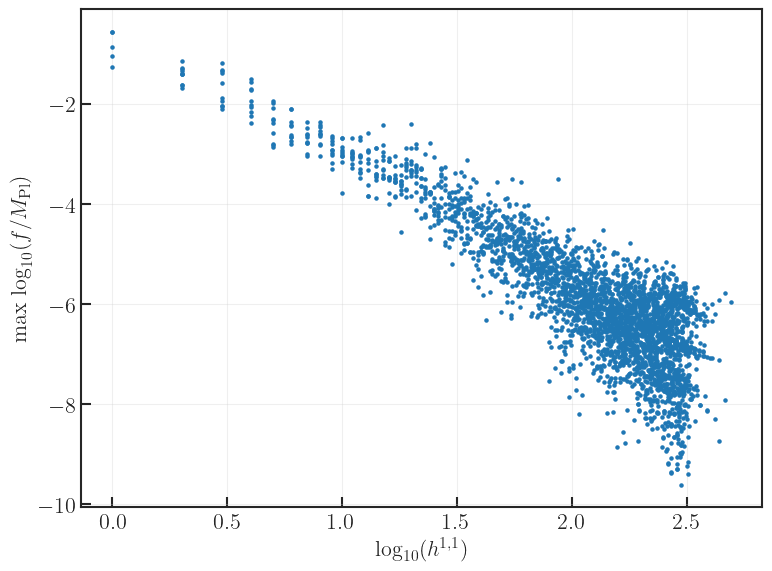

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

df = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/glimmers_approx.csv")

h11 = df["h11"].values
log10h11 = np.log10(h11)
maxlogf = df["max_log10_f_over_Mpl"].values

plt.figure(figsize=(8, 6))
plt.xlabel(r"$\log_{10}(h^{1,1})$")
plt.ylabel(r"max $\log_{10}(f/M_{\mathrm{Pl}})$")
plt.scatter(log10h11, maxlogf, s=5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("max_glimmers_f_as_fcn_of_h11.pdf")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("glimmers_approx.csv")
f = df['max_f_chol']


0       2.756644e-01
1       5.513289e-02
2       9.188815e-02
3       2.756644e-01
4       1.378322e-01
            ...     
3198    1.821214e-09
3199    7.718898e-08
3200    1.211301e-08
3201    1.669793e-06
3202    1.098890e-06
Name: max_f_chol, Length: 3203, dtype: float64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Mpl_eV = 2.435e27  
g_s = 0.1  

df = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/glimmers_with_string_scale.csv")
